# SQLite & CoinMarketCap API Notebook

This is a template notebook. The first heading should be the title of what notebook is about. For example, if it is a neo4j tutorial the heading should be `Neo4j API`.

- Add description of what the notebook does.
- Point to references, e.g. (neo4j.API.md)
- Add citations.
- Keep the notebook flow clear.
- Comments should be imperative and have a period at the end.
- Your code should be well commented. 

The name of this notebook should in the following format:
- if the notebook is exploring `pycaret API`, then it is `pycaret.API.ipynb`

Follow the reference to write notebooks in a clear manner: https://github.com/causify-ai/helpers/blob/master/docs/coding/all.jupyter_notebook.how_to_guide.md

In [3]:
%load_ext autoreload
%autoreload 2

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


## Imports

In [52]:
import logging
from requests import Request, Session
import pandas as pd
import sqlite3
import mplfinance as mpf
import yfinance as yf
import matplotlib.pyplot as plt
%matplotlib inline
import seaborn as sns
import sqlite_utils

# import helpers.hdbg as hdbg
# import helpers.hprint as hprint

## Configuration

In [8]:
# hdbg.init_logger(verbosity=logging.INFO)
# _LOG = logging.getLogger(__name__)
# hprint.config_notebook()

In [11]:
API_KEY = 'bdbd5008-53de-4bf9-b9b8-c1edb2c6afb0'
headers = {'X-CMC_PRO_API_KEY': API_KEY,'Accept': 'application/json'}
url = 'https://pro-api.coinmarketcap.com/v1/cryptocurrency/listings/latest'
params = {'limit': 1,'convert': 'USD'}

DATEFMT = "%Y-%m-%d-%H-%M-%S"

## Make the notebook flow clear
Each notebook needs to follow a clear and logical flow, e.g:
- Load data
- Compute stats
- Clean data
- Compute stats
- Do analysis
- Show results

# Testing API and Functions

## Load Data

In [66]:
data = sqlite_utils.fetchHistoricalBTC(ticker="BTC-USD", period='15y', interval='1d')
print(f"Shape of data: {data.shape}")

Shape of data: (3868, 6)


In [67]:
data.head()

,date,close,high,low,open,volume
0,2014-09-17-00-00-00,457.334015,468.174011,452.421997,465.864014,21056800
1,2014-09-18-00-00-00,424.440002,456.859985,413.104004,456.859985,34483200
2,2014-09-19-00-00-00,394.795990,427.834991,384.532013,424.102997,37919700
3,2014-09-20-00-00-00,408.903992,423.295990,389.882996,394.673004,36863600
4,2014-09-21-00-00-00,398.821014,412.425995,393.181000,408.084991,26580100


In [68]:
data.tail()

,date,close,high,low,open,volume
3863,2025-04-15-00-00-00,83668.992188,86429.351562,83598.820312,84539.695312,28040322885
3864,2025-04-16-00-00-00,84033.867188,85428.281250,83100.617188,83674.507812,29617804112
3865,2025-04-17-00-00-00,84895.750000,85449.070312,83749.750000,84030.671875,21276866029
3866,2025-04-18-00-00-00,84450.804688,85095.046875,84298.882812,84900.187500,12728372364
3867,2025-04-19-00-00-00,85404.562500,85464.789062,84363.656250,84450.289062,13500561408


## Storing Data into SQLite

In [69]:
%%time
sqlite_utils.storeData(data=data, db="./btcDaily.db")

CPU times: user 7.16 ms, sys: 3.5 ms, total: 10.7 ms
Wall time: 12.6 ms


## Query Data from SQLite

In [70]:
query = "SELECT * FROM btc_daily_stats"
data = sqlite_utils.fetchDB(query=query, db="./btcDaily.db")

In [71]:
print(f"Shape of data: {data.shape}")
data.head()

Shape of data: (3868, 6)


,date,close,high,low,open,volume
0,2014-09-17-00-00-00,457.334015,468.174011,452.421997,465.864014,21056800
1,2014-09-18-00-00-00,424.440002,456.859985,413.104004,456.859985,34483200
2,2014-09-19-00-00-00,394.795990,427.834991,384.532013,424.102997,37919700
3,2014-09-20-00-00-00,408.903992,423.295990,389.882996,394.673004,36863600
4,2014-09-21-00-00-00,398.821014,412.425995,393.181000,408.084991,26580100


## Live BTC Price

In [72]:
%%time
url = 'https://pro-api.coinmarketcap.com/v2/cryptocurrency/quotes/latest'
API_KEY = 'bdbd5008-53de-4bf9-b9b8-c1edb2c6afb0'
btcLiveData, btcAuxData = sqlite_utils.liveBTC(url=url, API_KEY=API_KEY)

CPU times: user 8.52 ms, sys: 2.59 ms, total: 11.1 ms
Wall time: 173 ms


In [73]:
print("Live Bitcoin Status:\n", btcLiveData)

Live Bitcoin Status:
 {'date': '2025-04-19-15-13-00', 'open': 85416.57252526576, 'volume': 13466822756.794626}


In [74]:
print("Live Bitcoin Additional Details:\n", btcAuxData)

Live Bitcoin Additional Details:
 {'price': 85416.57252526576, 'volume_24h': 13466822756.794626, 'volume_change_24h': -25.5473, 'percent_change_1h': -0.05491673, 'percent_change_24h': 1.1210075, 'percent_change_7d': 0.91433683, 'percent_change_30d': -0.67676211, 'percent_change_60d': -10.607883, 'percent_change_90d': -18.34055466, 'market_cap': 1695814676800.6077, 'market_cap_dominance': 62.9803, 'fully_diluted_market_cap': 1793748023030.58, 'tvl': None, 'last_updated': '2025-04-19T15:13:00.000Z'}


## Inserting Live Data into SQLite

In [75]:
sqlite_utils.addDatapoint(liveData=btcLiveData, db="./btcDaily.db")

# Analysis

In [80]:
query = "SELECT * FROM btc_daily_stats"
data = sqlite_utils.fetchDB(query=query, db="./btcDaily.db")

print(f"Shape of data: {data.shape}")

data.tail()

Shape of data: (3869, 6)


,date,close,high,low,open,volume
3864,2025-04-16-00-00-00,84033.867188,85428.281250,83100.617188,83674.507812,2.961780e+10
3865,2025-04-17-00-00-00,84895.750000,85449.070312,83749.750000,84030.671875,2.127687e+10
3866,2025-04-18-00-00-00,84450.804688,85095.046875,84298.882812,84900.187500,1.272837e+10
3867,2025-04-19-00-00-00,85404.562500,85464.789062,84363.656250,84450.289062,1.350056e+10
3868,2025-04-19-15-13-00,NaN,NaN,NaN,85416.572525,1.346682e+10


## Bitcoin Open Price

In [81]:
data['date'] = pd.to_datetime(data['date'], format=DATEFMT)

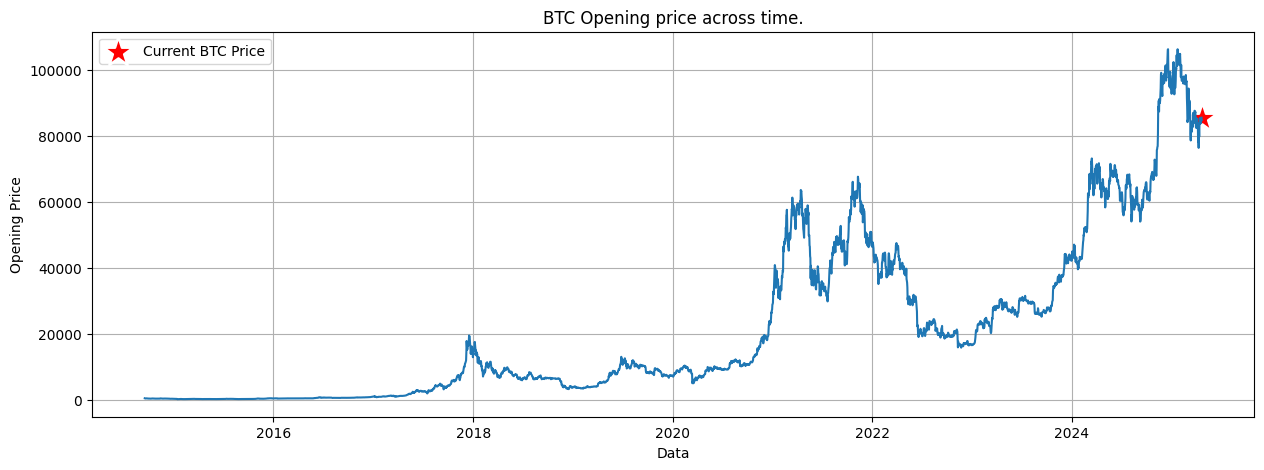

In [82]:
plt.figure(figsize=(15,5), dpi=100)
sns.lineplot(data=data, x='date', y='open')
sns.scatterplot(x=[data.iloc[-1]['date']], y=[data.iloc[-1]['open']], s=500, marker='*', color='red', label='Current BTC Price') 
plt.grid(True)
plt.xlabel("Date")
plt.ylabel("Opening Price")
plt.title("BTC Opening price across time.")
plt.show()

### Moving Average

In [83]:
query = '''SELECT 
    date,
    open,
    ROUND(AVG(open) OVER (
        ORDER BY date 
        ROWS BETWEEN 1 PRECEDING AND CURRENT ROW
    ), 2) AS ma_2d_open, --Adding 2 Day Moving Average
    
    ROUND(AVG(open) OVER (
        ORDER BY date 
        ROWS BETWEEN 29 PRECEDING AND CURRENT ROW
    ), 2) AS ma_30d_open, --Adding 30 Day Moving Average
    
    ROUND(AVG(open) OVER (
        ORDER BY date 
        ROWS BETWEEN 119 PRECEDING AND CURRENT ROW
    ), 2) AS ma_120d_open --Adding 120 Day Moving Average
FROM btc_daily_stats
ORDER BY date;
'''
dataMA = sqlite_utils.fetchDB(query=query, db="./btcDaily.db")
dataMA['date'] = pd.to_datetime(dataMA['date'], format=DATEFMT)
dataMA.tail()

,date,open,ma_2d_open,ma_30d_open,ma_120d_open
3864,2025-04-16 00:00:00,83674.507812,84107.10,83576.24,92423.06
3865,2025-04-17 00:00:00,84030.671875,83852.59,83574.74,92238.76
3866,2025-04-18 00:00:00,84900.187500,84465.43,83647.46,92112.34
3867,2025-04-19 00:00:00,84450.289062,84675.24,83566.70,92003.72
3868,2025-04-19 15:13:00,85416.572525,84933.43,83608.43,91900.89


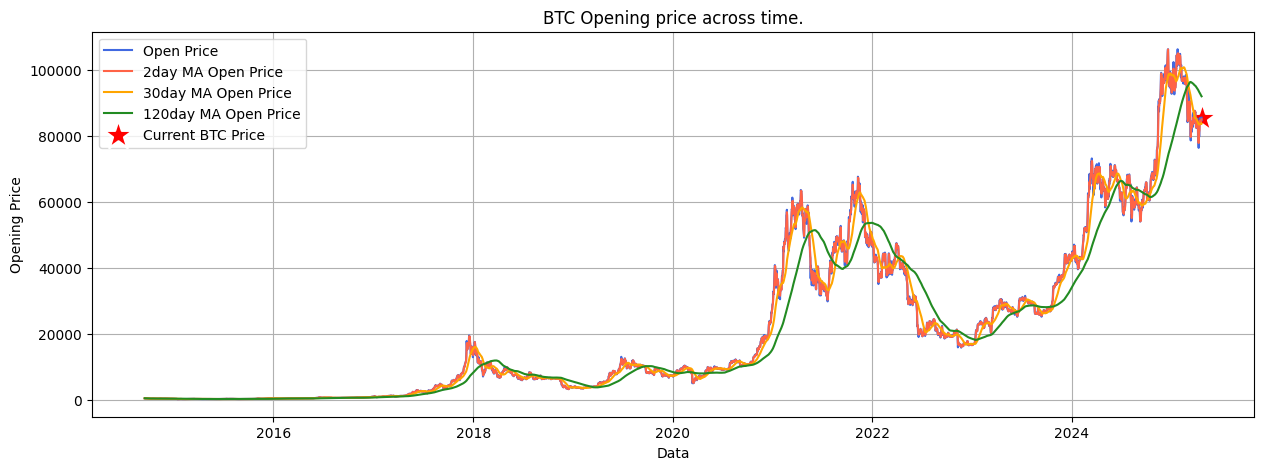

In [84]:
plt.figure(figsize=(15,5), dpi=100)
sns.lineplot(data=dataMA, x='date', y='open', label='Open Price', color='royalblue')
sns.lineplot(data=dataMA, x='date', y='ma_2d_open', label='2day MA Open Price', color='tomato')
sns.lineplot(data=dataMA, x='date', y='ma_30d_open', label='30day MA Open Price', color='orange')
sns.lineplot(data=dataMA, x='date', y='ma_120d_open', label='120day MA Open Price', color='forestgreen')

sns.scatterplot(x=[dataMA.iloc[-1]['date']], y=[dataMA.iloc[-1]['open']], s=500, marker='*', color='red', label='Current BTC Price') 
plt.grid(True)
plt.xlabel("Date")
plt.ylabel("Opening Price")
plt.title("BTC Opening price across time.")
plt.show()

### Moving Average - Data Range

In [85]:
dateStart, dateEnd = '2024-12-24-00-00-00', '2025-04-15-00-00-00'

query = f'''SELECT 
    date,
    open,
    ROUND(AVG(open) OVER (
        ORDER BY date 
        ROWS BETWEEN 1 PRECEDING AND CURRENT ROW
    ), 2) AS ma_2d_open,
    
    ROUND(AVG(open) OVER (
        ORDER BY date 
        ROWS BETWEEN 29 PRECEDING AND CURRENT ROW
    ), 2) AS ma_30d_open,
    
    ROUND(AVG(open) OVER (
        ORDER BY date 
        ROWS BETWEEN 119 PRECEDING AND CURRENT ROW
    ), 2) AS ma_120d_open
FROM btc_daily_stats
WHERE date BETWEEN '{dateStart}' AND '{dateEnd}' --Adding Date Range
ORDER BY date;
'''

dataMA = sqlite_utils.fetchDB(query=query, db="./btcDaily.db")
dataMA['date'] = pd.to_datetime(dataMA['date'], format=DATEFMT)
dataMA.tail()

,date,open,ma_2d_open,ma_30d_open,ma_120d_open
108,2025-04-11,79625.046875,81095.51,83412.15,92444.02
109,2025-04-12,83404.515625,81514.78,83401.47,92361.84
110,2025-04-13,85279.468750,84341.99,83541.89,92298.04
111,2025-04-14,83694.523438,84487.00,83532.76,92221.22
112,2025-04-15,84539.695312,84117.11,83539.64,92153.24


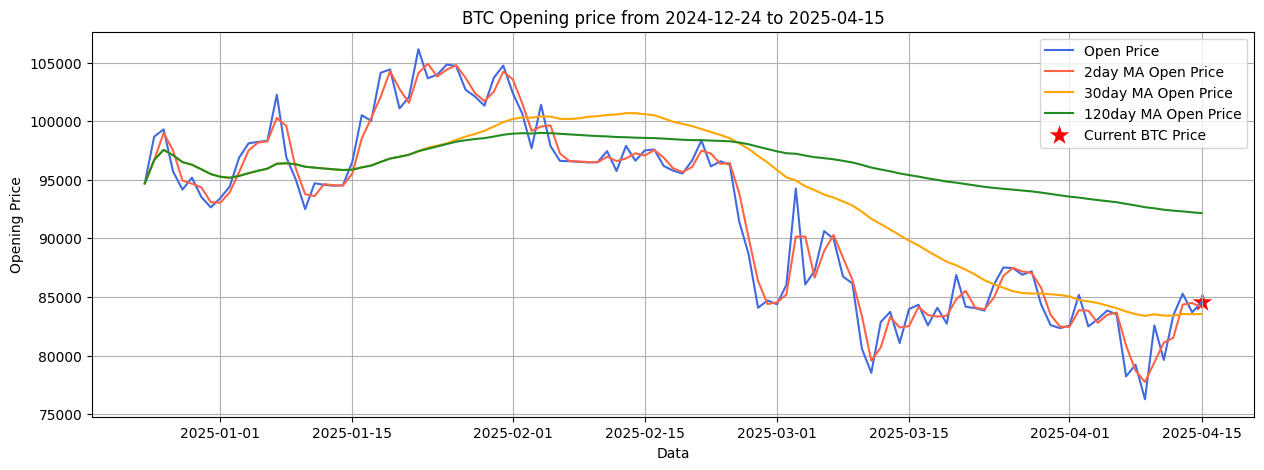

In [87]:
plt.figure(figsize=(15,5), dpi=100)
sns.lineplot(data=dataMA, x='date', y='open', label='Open Price', color='royalblue')
sns.lineplot(data=dataMA, x='date', y='ma_2d_open', label='2day MA Open Price', color='tomato')
sns.lineplot(data=dataMA, x='date', y='ma_30d_open', label='30day MA Open Price', color='orange')
sns.lineplot(data=dataMA, x='date', y='ma_120d_open', label='120day MA Open Price', color='forestgreen')

sns.scatterplot(x=[dataMA.iloc[-1]['date']], y=[dataMA.iloc[-1]['open']], s=400, marker='*', color='red', label='Current BTC Price') 
plt.grid(True)
plt.xlabel("Data")
plt.ylabel("Opening Price")

plt.title(f"BTC Opening price from {dateStart[:10]} to {dateEnd[:10]}")
plt.show()

## Bitcoin Volume

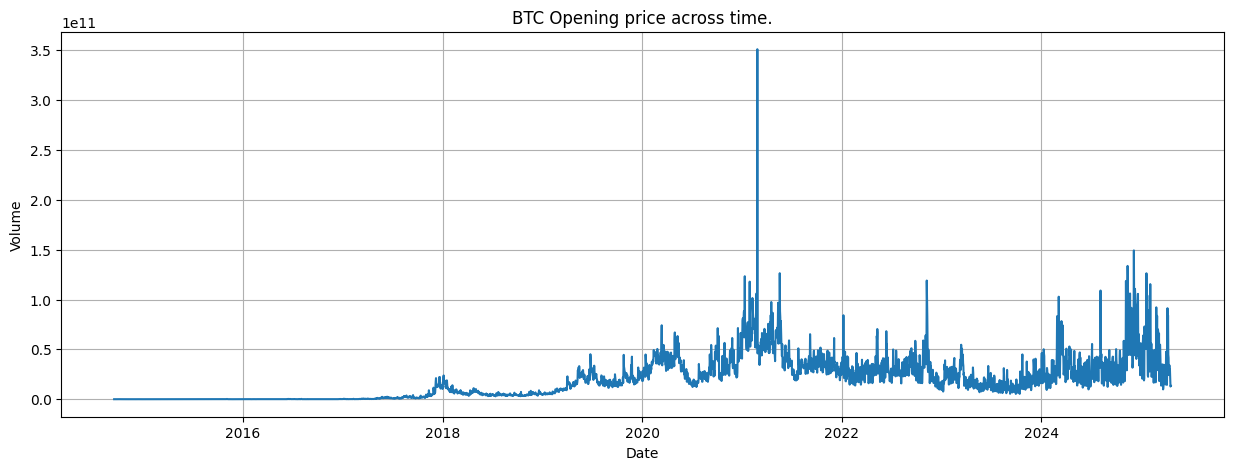

In [89]:
plt.figure(figsize=(15,5), dpi=100)
sns.lineplot(data=data, x='date', y='volume')
plt.title("BTC Opening price across time.")
plt.grid(True)
plt.xlabel("Date")
plt.ylabel("Volume")
plt.show()

### Moving average

In [96]:
query = '''SELECT 
    date,
    volume,
    ROUND(AVG(volume) OVER (
        ORDER BY date 
        ROWS BETWEEN 1 PRECEDING AND CURRENT ROW
    ), 2) AS ma_2d_vol, --Adding 2 Day Moving Average
    
    ROUND(AVG(volume) OVER (
        ORDER BY date 
        ROWS BETWEEN 29 PRECEDING AND CURRENT ROW
    ), 2) AS ma_30d_vol, --Adding 30 Day Moving Average
    
    ROUND(AVG(volume) OVER (
        ORDER BY date 
        ROWS BETWEEN 119 PRECEDING AND CURRENT ROW
    ), 2) AS ma_120d_vol --Adding 120 Day Moving Average
FROM btc_daily_stats
ORDER BY date;
'''
dataMA = sqlite_utils.fetchDB(query=query, db="./btcDaily.db")
dataMA['date'] = pd.to_datetime(dataMA['date'], format=DATEFMT)
dataMA.tail()

,date,volume,ma_2d_vol,ma_30d_vol,ma_120d_vol
3864,2025-04-16 00:00:00,2.961780e+10,2.882906e+10,3.345339e+10,4.524742e+10
3865,2025-04-17 00:00:00,2.127687e+10,2.544734e+10,3.335943e+10,4.464252e+10
3866,2025-04-18 00:00:00,1.272837e+10,1.700262e+10,3.261931e+10,4.393841e+10
3867,2025-04-19 00:00:00,1.350056e+10,1.311447e+10,3.210170e+10,4.317063e+10
3868,2025-04-19 15:13:00,1.346682e+10,1.348369e+10,3.191624e+10,4.285147e+10


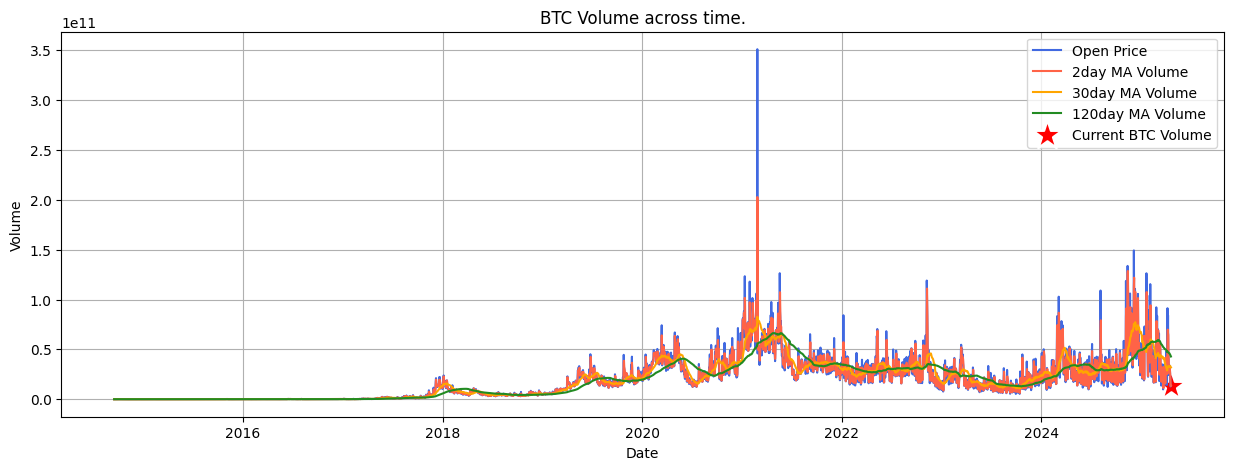

In [97]:
plt.figure(figsize=(15,5), dpi=100)
sns.lineplot(data=dataMA, x='date', y='volume', label='Open Price', color='royalblue')
sns.lineplot(data=dataMA, x='date', y='ma_2d_vol', label='2day MA Volume', color='tomato')
sns.lineplot(data=dataMA, x='date', y='ma_30d_vol', label='30day MA Volume', color='orange')
sns.lineplot(data=dataMA, x='date', y='ma_120d_vol', label='120day MA Volume', color='forestgreen')

sns.scatterplot(x=[dataMA.iloc[-1]['date']], y=[dataMA.iloc[-1]['volume']], s=500, marker='*', color='red', label='Current BTC Volume') 
plt.grid(True)
plt.xlabel("Date")
plt.ylabel("Volume")

plt.title("BTC Volume across time.")
plt.show()

### Moving Average - Data Range

In [98]:
dateStart, dateEnd = '2024-12-24-00-00-00', '2025-04-15-00-00-00'

query = f'''SELECT 
    date,
    volume,
    ROUND(AVG(volume) OVER (
        ORDER BY date 
        ROWS BETWEEN 1 PRECEDING AND CURRENT ROW
    ), 2) AS ma_2d_vol,
    
    ROUND(AVG(volume) OVER (
        ORDER BY date 
        ROWS BETWEEN 29 PRECEDING AND CURRENT ROW
    ), 2) AS ma_30d_vol,
    
    ROUND(AVG(volume) OVER (
        ORDER BY date 
        ROWS BETWEEN 119 PRECEDING AND CURRENT ROW
    ), 2) AS ma_120d_vol
FROM btc_daily_stats
WHERE date BETWEEN '{dateStart}' AND '{dateEnd}' --Adding Date Range
ORDER BY date;
'''

dataMA = sqlite_utils.fetchDB(query=query, db="./btcDaily.db")
dataMA['date'] = pd.to_datetime(dataMA['date'], format=DATEFMT)
dataMA.tail()

,date,volume,ma_2d_vol,ma_30d_vol,ma_120d_vol
108,2025-04-11,41656778779,4.318739e+10,3.266242e+10,4.429370e+10
109,2025-04-12,24258059104,3.295742e+10,3.242392e+10,4.411156e+10
110,2025-04-13,28796984817,2.652752e+10,3.239755e+10,4.397359e+10
111,2025-04-14,34090769777,3.144388e+10,3.307889e+10,4.388535e+10
112,2025-04-15,28040322885,3.106555e+10,3.330256e+10,4.374513e+10


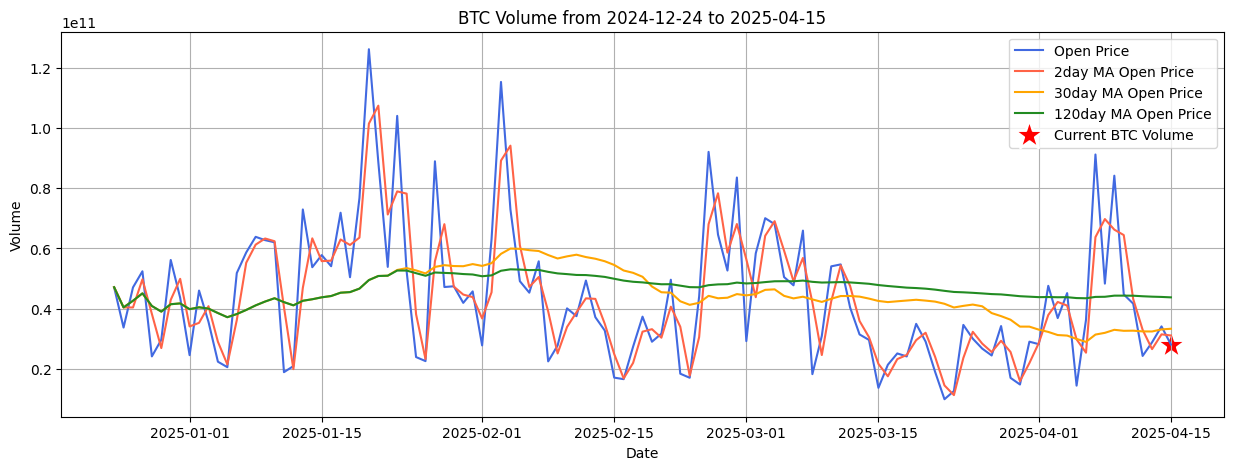

In [99]:
plt.figure(figsize=(15,5), dpi=100)
sns.lineplot(data=dataMA, x='date', y='volume', label='Open Price', color='royalblue')
sns.lineplot(data=dataMA, x='date', y='ma_2d_vol', label='2day MA Open Price', color='tomato')
sns.lineplot(data=dataMA, x='date', y='ma_30d_vol', label='30day MA Open Price', color='orange')
sns.lineplot(data=dataMA, x='date', y='ma_120d_vol', label='120day MA Open Price', color='forestgreen')

sns.scatterplot(x=[dataMA.iloc[-1]['date']], y=[dataMA.iloc[-1]['volume']], s=500, marker='*', color='red', label='Current BTC Volume') 
plt.grid(True)
plt.xlabel("Date")
plt.ylabel("Volume")

plt.title(f"BTC Volume from {dateStart[:10]} to {dateEnd[:10]}")
plt.show()

## Candlestick Analysis Plot

In [100]:
dateStart, dateEnd = '2024-08-24-00-00-00', '2025-04-15-00-00-00'

query = f"SELECT * FROM btc_daily_stats WHERE date BETWEEN '{dateStart}' AND '{dateEnd}' --Adding Date Range"
dataCS = sqlite_utils.fetchDB(query=query, db="./btcDaily.db")

dataCS['date'] = pd.to_datetime(dataCS['date'], format=DATEFMT)

In [101]:
dataCS['SMA'] = dataCS.open.rolling(window=20).mean()
dataCS['stddev'] = dataCS.open.rolling(window=20).std()
dataCS['upper'] = dataCS.SMA + 2 * dataCS.stddev
dataCS['lower'] = dataCS.SMA - 2 * dataCS.stddev
dataCS.set_index('date', inplace=True)

tcdf = dataCS[['lower','upper','SMA']]

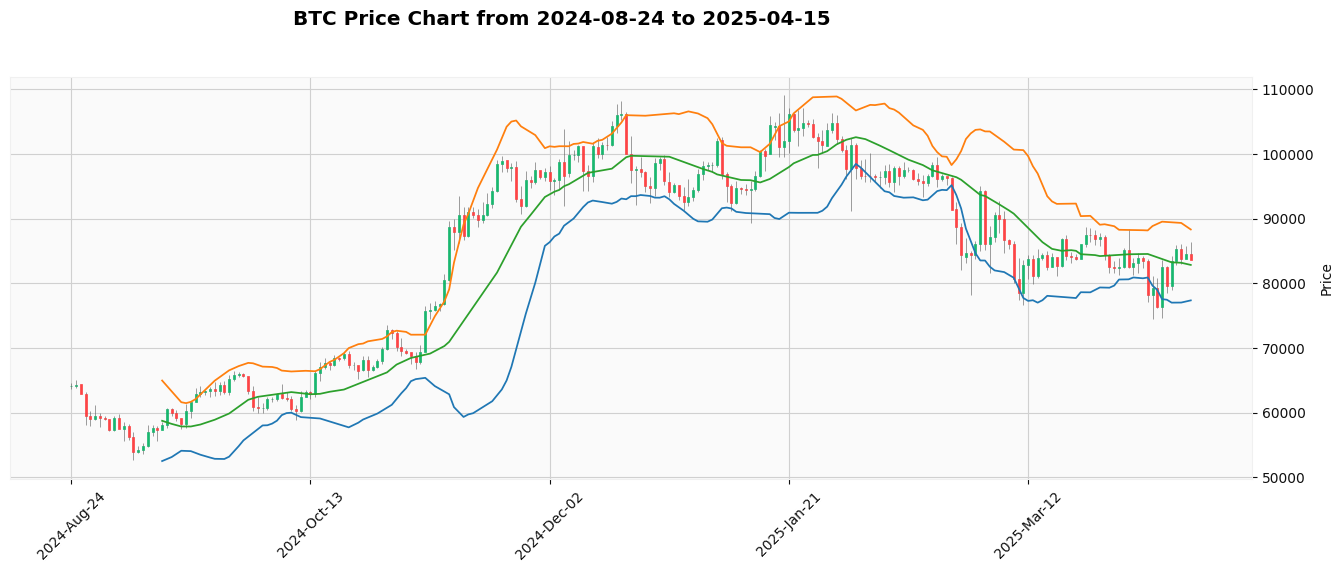

In [102]:
apd = mpf.make_addplot(tcdf)
mpf.plot(dataCS, figratio=(15,5), type='candle', addplot=apd, volume=False, style='yahoo',title=f'BTC Price Chart from {dateStart[:10]} to {dateEnd[:10]}')

## Rate Of Change

In [104]:
dateStart, dateEnd = '2024-12-01-00-00-00', '2025-04-15-00-00-00'

query = f'''SELECT 
    date,
    open,
    -- 1-day Rate of Change
    ROUND(((open - LAG(open, 1) OVER (ORDER BY date)) / LAG(open, 1) OVER (ORDER BY date)) * 100, 2) AS roc_1d,

    -- 30-day Rate of Change
    ROUND(((open - LAG(open, 30) OVER (ORDER BY date)) / LAG(open, 30) OVER (ORDER BY date)) * 100, 2) AS roc_30d,

    -- 120-day Rate of Change
    ROUND(((open - LAG(open, 120) OVER (ORDER BY date)) / LAG(open, 120) OVER (ORDER BY date)) * 100, 2) AS roc_120d

FROM btc_daily_stats
WHERE date BETWEEN '{dateStart}' AND '{dateEnd}'
ORDER BY date'''

dataRC = sqlite_utils.fetchDB(query=query, db="./btcDaily.db")
dataRC['date'] = pd.to_datetime(dataRC['date'], format=DATEFMT)

dataRC.tail()

,date,open,roc_1d,roc_30d,roc_120d
131,2025-04-11,79625.046875,-3.56,-3.90,-21.29
132,2025-04-12,83404.515625,4.75,-0.38,-16.63
133,2025-04-13,85279.468750,2.25,5.20,-15.94
134,2025-04-14,83694.523438,-1.86,-0.33,-17.44
135,2025-04-15,84539.695312,1.01,0.24,-18.94


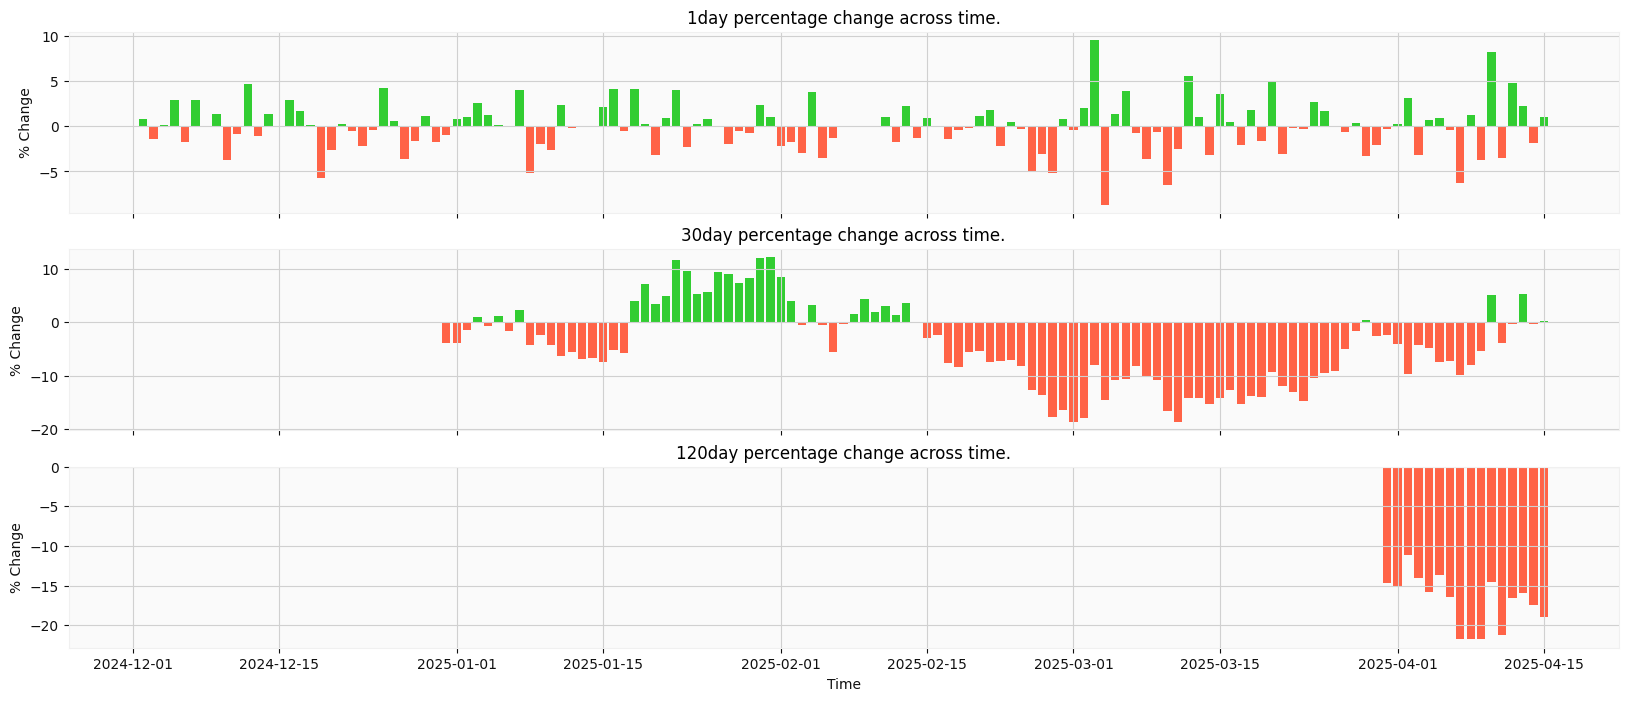

In [105]:
f, ax = plt.subplots(nrows=3,ncols=1, figsize=(20,8), sharex=True)

colors = ['tomato' if val <=0 else 'limegreen' for val in dataRC['roc_1d']]
ax[0].bar(x=dataRC['date'], height=dataRC['roc_1d'], color=colors)
ax[0].set_title("1day percentage change across time.")
ax[0].set_ylabel("% Change")

colors = ['tomato' if val <=0 else 'limegreen' for val in dataRC['roc_30d']]
ax[1].bar(x=dataRC['date'], height=dataRC['roc_30d'], color=colors)
ax[1].set_title("30day percentage change across time.")
ax[1].set_ylabel("% Change")

colors = ['tomato' if val <=0 else 'limegreen' for val in dataRC['roc_120d']]
ax[2].bar(x=dataRC['date'], height=dataRC['roc_120d'], color=colors)
ax[2].set_title("120day percentage change across time.")
ax[2].set_xlabel("Time")
ax[2].set_ylabel("% Change")

plt.show()

## Volatility

In [106]:
dateStart, dateEnd = '2024-04-01-00-00-00', '2025-04-15-00-00-00'

query = f'''SELECT 
    date,
    open,
    -- 1-day Rate of Change
    ROUND(((open - LAG(open, 1) OVER (ORDER BY date)) / LAG(open, 1) OVER (ORDER BY date)) * 100, 2) AS roc_1d,

    -- 30-day Rate of Change
    ROUND(((open - LAG(open, 30) OVER (ORDER BY date)) / LAG(open, 30) OVER (ORDER BY date)) * 100, 2) AS roc_30d,

    -- 120-day Rate of Change
    ROUND(((open - LAG(open, 120) OVER (ORDER BY date)) / LAG(open, 120) OVER (ORDER BY date)) * 100, 2) AS roc_120d

FROM btc_daily_stats
WHERE date BETWEEN '{dateStart}' AND '{dateEnd}'
ORDER BY date'''

dataV = sqlite_utils.fetchDB(query=query, db="./btcDaily.db")
dataV['date'] = pd.to_datetime(dataV['date'], format=DATEFMT)

In [107]:
dataV['daily_return'] = dataV['open'].pct_change()
dataV['volatility_2d'] = dataV['daily_return'].rolling(window=5).std()
dataV['volatility_30d'] = dataV['daily_return'].rolling(window=30).std()
dataV['volatility_120d'] = dataV['daily_return'].rolling(window=120).std()

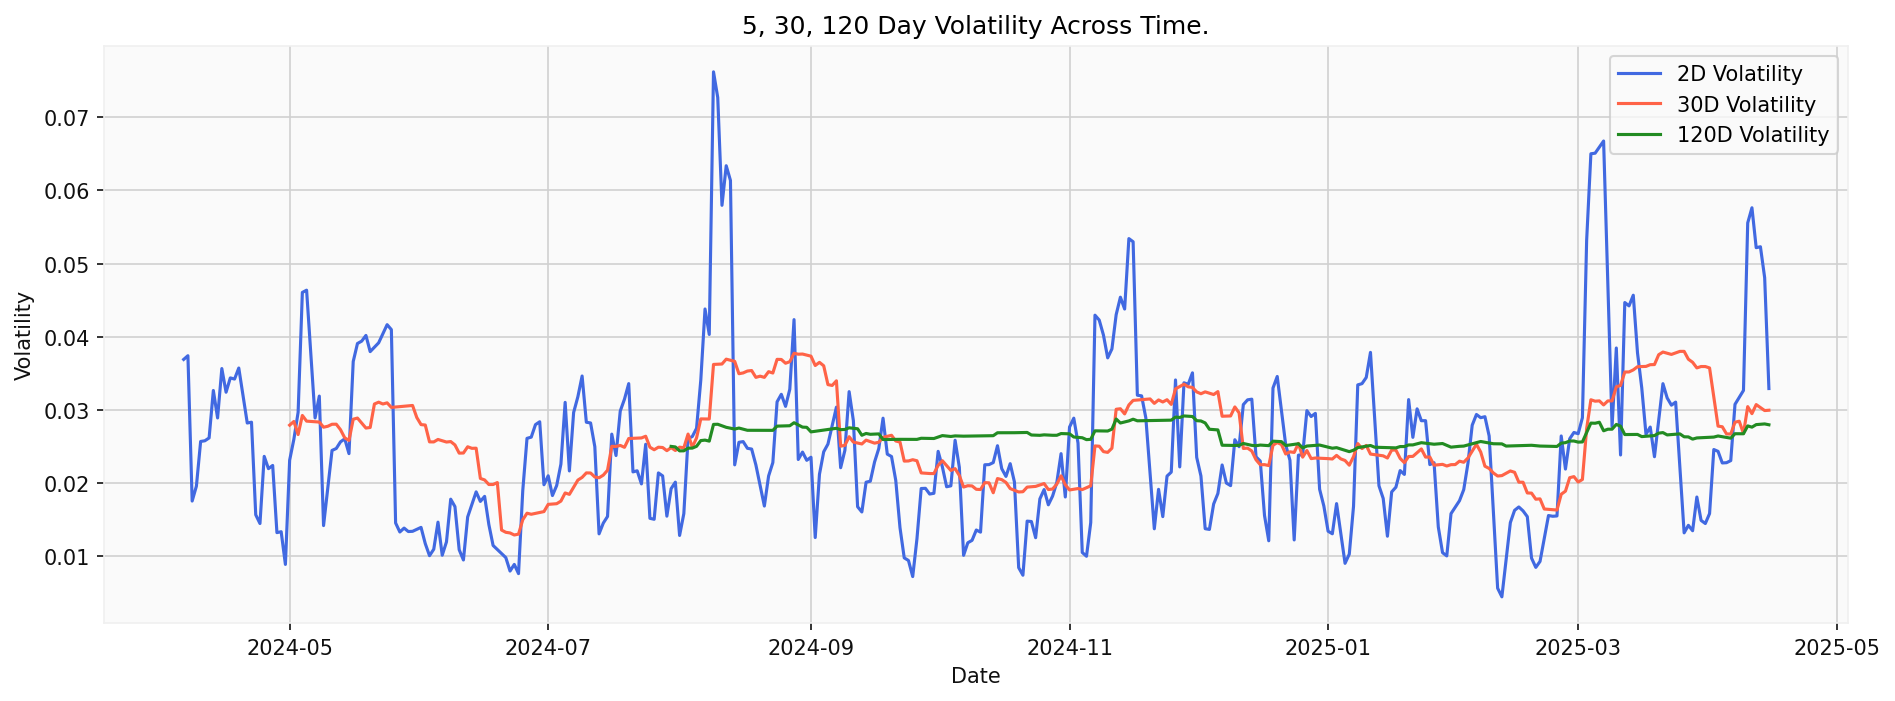

In [113]:
plt.figure(figsize=(15,5), dpi=150)
sns.lineplot(data=dataV, x='date', y='volatility_2d', label='2D Volatility', color='royalblue')
sns.lineplot(data=dataV, x='date', y='volatility_30d', label='30D Volatility', color='tomato')
sns.lineplot(data=dataV, x='date', y='volatility_120d', label='120D Volatility', color='forestgreen')
plt.title("5, 30, 120 Day Volatility Across Time.")
plt.xlabel("Date")
plt.ylabel("Volatility")
plt.show()

## Histogram of Daily Records

In [109]:
dateStart, dateEnd = '2024-04-01-00-00-00', '2025-04-15-00-00-00'

query = f'''SELECT 
    date,
    open,
    -- 1-day Rate of Change
    ROUND(((open - LAG(open, 1) OVER (ORDER BY date)) / LAG(open, 1) OVER (ORDER BY date)) * 100, 2) AS roc_1d,

    -- 30-day Rate of Change
    ROUND(((open - LAG(open, 30) OVER (ORDER BY date)) / LAG(open, 30) OVER (ORDER BY date)) * 100, 2) AS roc_30d,

    -- 120-day Rate of Change
    ROUND(((open - LAG(open, 120) OVER (ORDER BY date)) / LAG(open, 120) OVER (ORDER BY date)) * 100, 2) AS roc_120d

FROM btc_daily_stats
WHERE date BETWEEN '{dateStart}' AND '{dateEnd}'
ORDER BY date'''

dataV = sqlite_utils.fetchDB(query=query, db="./btcDaily.db")
dataV['date'] = pd.to_datetime(dataV['date'], format=DATEFMT)

In [114]:
dataV['daily_return'] = dataV['open'].pct_change()
dataV['volatility_2d'] = dataV['daily_return'].rolling(window=5).std()
dataV['volatility_30d'] = dataV['daily_return'].rolling(window=30).std()
dataV['volatility_120d'] = dataV['daily_return'].rolling(window=120).std()

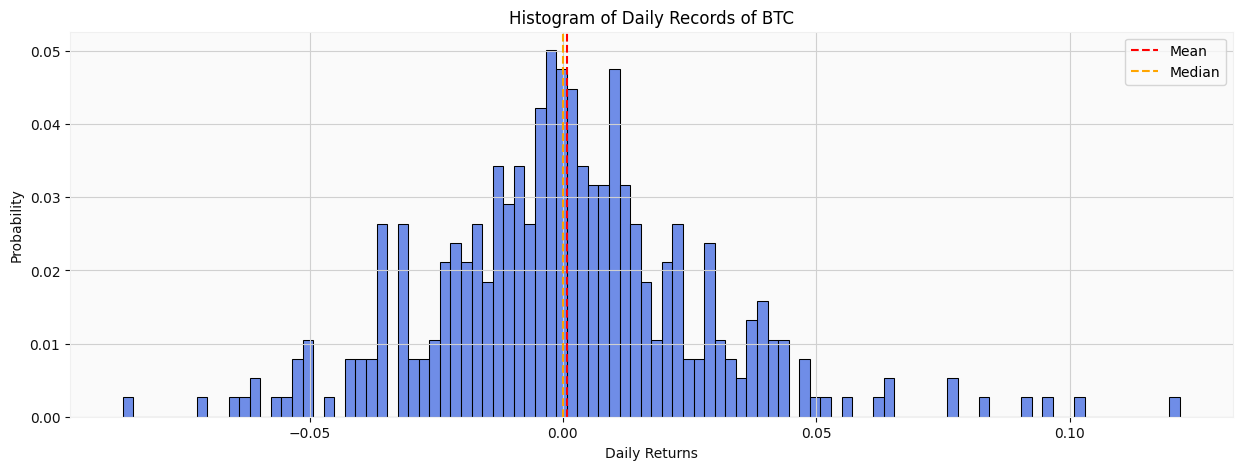

In [111]:
plt.figure(figsize=(15,5), dpi=100)
sns.histplot(data=dataV['daily_return'].dropna(), color='royalblue', bins=100, stat='probability',edgecolor='black')
plt.axvline(x = dataV['daily_return'].dropna().mean(), color ='red', linestyle ="--",linewidth=1.5, label = 'Mean') 
plt.axvline(x = dataV['daily_return'].dropna().median(), color ='orange', linestyle ="--",linewidth=1.5, label = 'Median') 
plt.legend()
plt.title("Histogram of Daily Records of BTC")
plt.xlabel("Daily Returns")
plt.ylabel("Probability")
plt.show()